In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('/content/Zomato_Data.csv')

# 2. Clean 'rate' column
def transform_rate(value):
    if isinstance(value, str):
        value = value.split('/')[0].strip()
        if value in ['NEW', '-']:
            return np.nan
        return float(value)
    return value

df['rate'] = df['rate'].apply(transform_rate)

# 3. Clean 'approx_cost(for two people)'
if 'approx_cost(for two people)' in df.columns:
    df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '').replace('nan', '0').astype(float)

# 4. Feature Engineering
df = df.dropna(subset=['rate', 'approx_cost(for two people)', 'votes', 'listed_in(type)'])
engineered_df = df.copy()

engineered_df['cost_per_person'] = engineered_df['approx_cost(for two people)'] / 2
engineered_df['online_order_binary'] = engineered_df['online_order'].map({'Yes': 1, 'No': 0})
engineered_df['book_table_binary'] = engineered_df['book_table'].map({'Yes': 1, 'No': 0})

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Data cleaning and feature engineering complete. 'engineered_df' is ready.")
display(engineered_df.head())

Data cleaning and feature engineering complete. 'engineered_df' is ready.


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type),cost_per_person,online_order_binary,book_table_binary
0,Jalsa,Yes,Yes,4.1,775,800.0,Buffet,400.0,1,1
1,Spice Elephant,Yes,No,4.1,787,800.0,Buffet,400.0,1,0
2,San Churro Cafe,Yes,No,3.8,918,800.0,Buffet,400.0,1,0
3,Addhuri Udupi Bhojana,No,No,3.7,88,300.0,Buffet,150.0,0,0
4,Grand Village,No,No,3.8,166,600.0,Buffet,300.0,0,0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Using the variables already in the kernel from our previous run
# engineered_df contains the cleaned and processed data
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

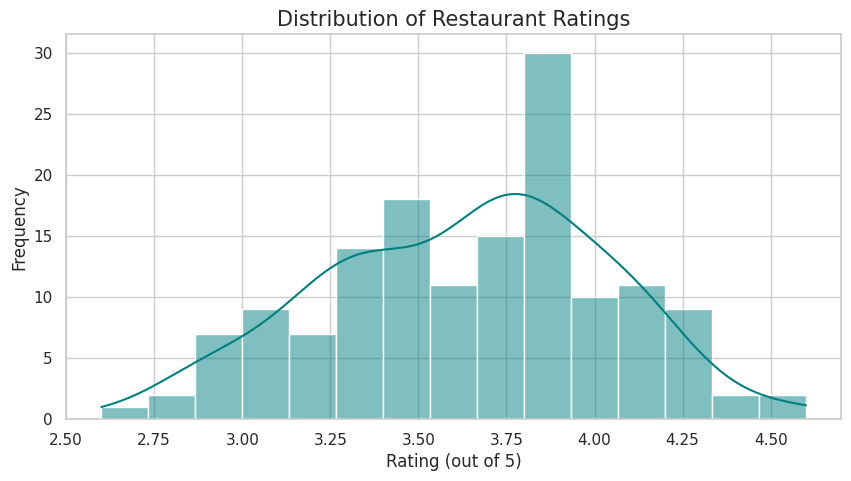

INSIGHT: The average restaurant rating is 3.63. The distribution shows most restaurants are clustered between 3.5 and 4.2.


In [21]:
# 1. Distribution of Restaurant Ratings
plt.figure(figsize=(10, 5))
sns.histplot(engineered_df['rate'], bins=15, kde=True, color='teal')
plt.title('Distribution of Restaurant Ratings', fontsize=15)
plt.xlabel('Rating (out of 5)')
plt.ylabel('Frequency')
plt.show()

# Insight 1: General Quality
avg_rating = engineered_df['rate'].mean()
print(f"INSIGHT: The average restaurant rating is {avg_rating:.2f}. The distribution shows most restaurants are clustered between 3.5 and 4.2.")

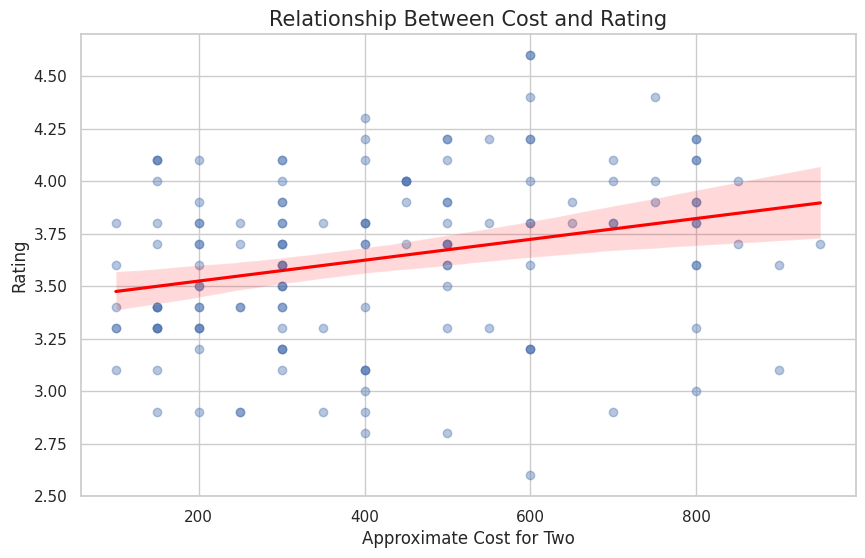

INSIGHT: The correlation between cost and rating is 0.28. While more expensive restaurants tend to have slightly higher ratings, price is not the only factor for quality.


In [22]:
# 2. Cost vs Rating Analysis
plt.figure(figsize=(10, 6))
sns.regplot(data=engineered_df, x='approx_cost(for two people)', y='rate',
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Relationship Between Cost and Rating', fontsize=15)
plt.xlabel('Approximate Cost for Two')
plt.ylabel('Rating')
plt.show()

# Insight 2: Cost vs Quality
corr_cost_rate = engineered_df['approx_cost(for two people)'].corr(engineered_df['rate'])
print(f"INSIGHT: The correlation between cost and rating is {corr_cost_rate:.2f}. While more expensive restaurants tend to have slightly higher ratings, price is not the only factor for quality.")

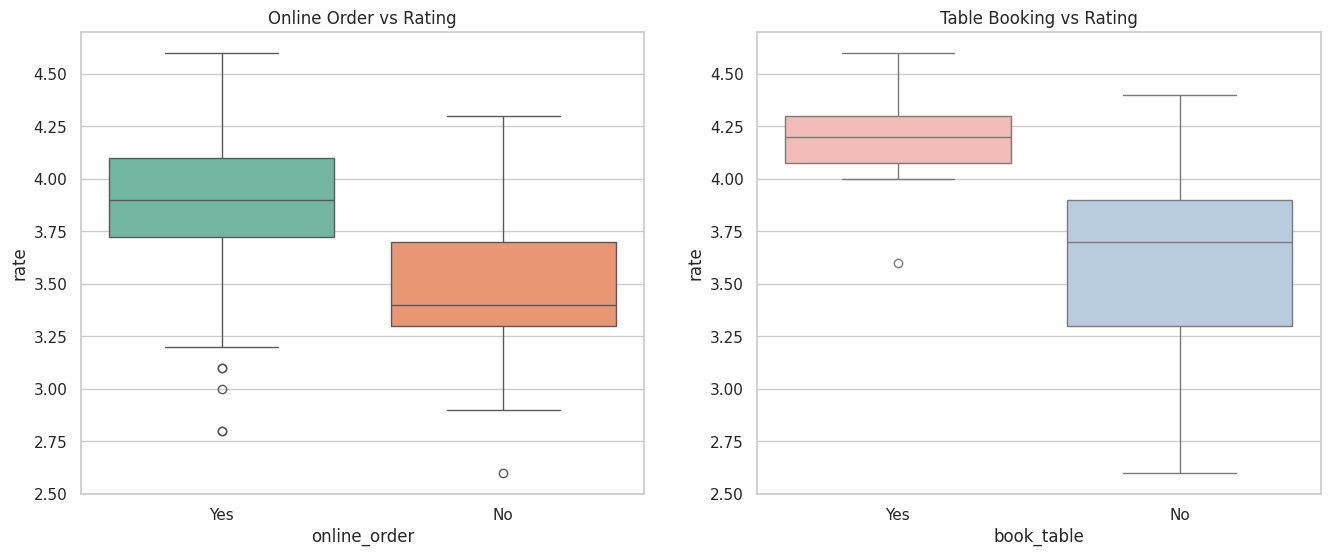

INSIGHT: Online ordering significantly impacts user satisfaction. Restaurants with online ordering average a 3.86 rating vs 3.49 for those without.


In [23]:
# 3. Impact of Services on Ratings
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=engineered_df, x='online_order', y='rate', ax=ax1, palette='Set2', hue='online_order', legend=False)
ax1.set_title('Online Order vs Rating')

sns.boxplot(data=engineered_df, x='book_table', y='rate', ax=ax2, palette='Pastel1', hue='book_table', legend=False)
ax2.set_title('Table Booking vs Rating')
plt.show()

# Insight 3: Online Order Impact
avg_rate_online = engineered_df.groupby('online_order')['rate'].mean()
print(f"INSIGHT: Online ordering significantly impacts user satisfaction. Restaurants with online ordering average a {avg_rate_online['Yes']:.2f} rating vs {avg_rate_online['No']:.2f} for those without.")

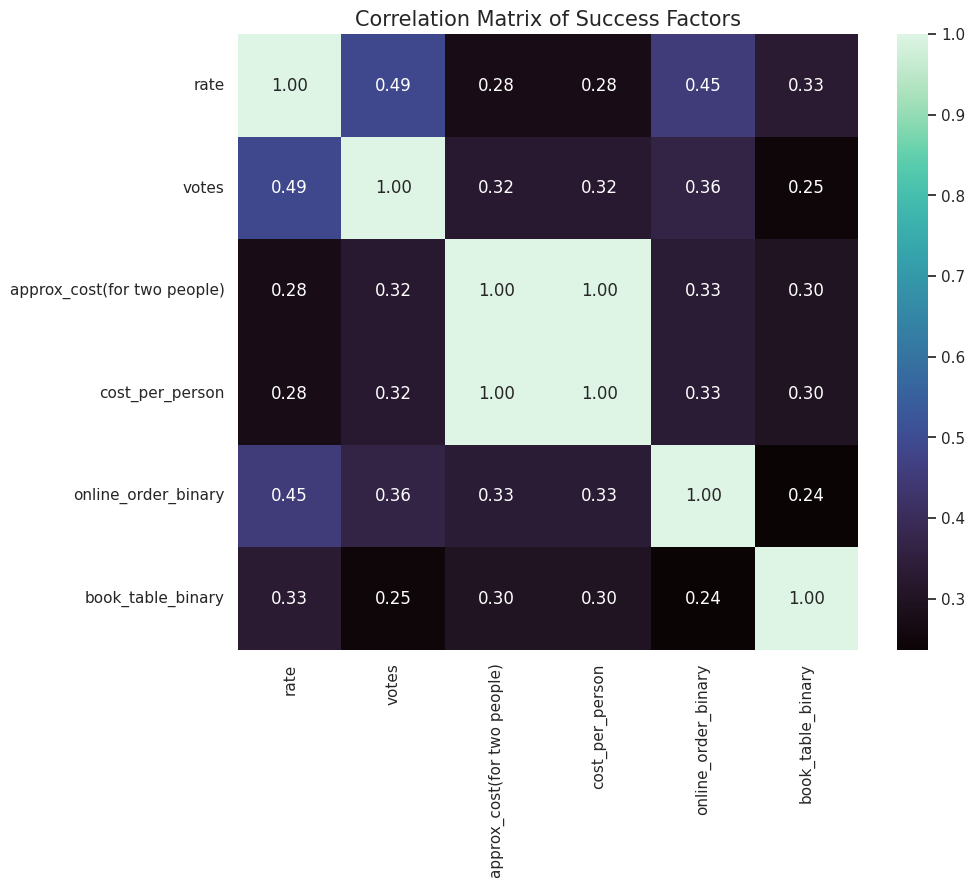

INSIGHT: Customer engagement (Votes) shows the strongest correlation with ratings (0.49), suggesting that popular restaurants are generally rated higher by the community.


In [24]:
# 4. Correlation Analysis
numeric_cols = ['rate', 'votes', 'approx_cost(for two people)', 'cost_per_person', 'online_order_binary', 'book_table_binary']
plt.figure(figsize=(10, 8))
sns.heatmap(engineered_df[numeric_cols].corr(), annot=True, cmap='mako', fmt='.2f')
plt.title('Correlation Matrix of Success Factors', fontsize=15)
plt.show()

# Insight 4: Engagement Driver
corr_votes_rate = engineered_df['votes'].corr(engineered_df['rate'])
print(f"INSIGHT: Customer engagement (Votes) shows the strongest correlation with ratings ({corr_votes_rate:.2f}), suggesting that popular restaurants are generally rated higher by the community.")

In [16]:
# 5. Top 10 High-Performing Restaurants
# Logic: Sort by Rating then by Votes to ensure quality and popularity
top_10 = engineered_df.sort_values(by=['rate', 'votes'], ascending=False).head(10)
print("TOP 10 RESTAURANTS BY RATING AND ENGAGEMENT")
# Only display available columns (location is removed as it's not in the CSV)
display(top_10[['name', 'rate', 'votes', 'listed_in(type)']])

TOP 10 RESTAURANTS BY RATING AND ENGAGEMENT


,name,rate,votes,listed_in(type)
7,Onesta,4.6,2556,Cafes
44,Onesta,4.6,2556,other
38,Empire Restaurant,4.4,4884,other
86,Meghana Foods,4.4,4401,Dining
52,Corner House Ice Cream,4.3,345,Dining
37,Szechuan Dragon,4.2,1647,Dining
9,Smacznego,4.2,504,Cafes
34,Faasos,4.2,415,other
57,Wamama,4.2,354,other
60,Peppy Peppers,4.2,244,other


In [17]:
# 6. Key Business Insights Summary
print("--- KEY BUSINESS INSIGHTS ---\n")

# Insight 1: Online Order Impact
avg_rate_online = engineered_df.groupby('online_order')['rate'].mean()
print(f"1. Online Order Impact: Restaurants with online ordering average a {avg_rate_online['Yes']:.2f} rating vs {avg_rate_online['No']:.2f} for those without.")

# Insight 2: Cost vs Quality
corr_cost_rate = engineered_df['approx_cost(for two people)'].corr(engineered_df['rate'])
print(f"2. Cost vs Quality: The correlation between cost and rating is {corr_cost_rate:.2f}, suggesting a moderate positive relationship.")

# Insight 3: Engagement Driver
corr_votes_rate = engineered_df['votes'].corr(engineered_df['rate'])
print(f"3. Engagement Driver: Votes have a correlation of {corr_votes_rate:.2f} with ratings, indicating that highly-rated restaurants attract significantly more engagement.")

# Insight 4: Category Performance
best_type = engineered_df.groupby('listed_in(type)')['rate'].mean().idxmax()
print(f"4. Category Performance: The '{best_type}' category tends to have the highest average customer ratings.")

--- KEY BUSINESS INSIGHTS ---

1. Online Order Impact: Restaurants with online ordering average a 3.86 rating vs 3.49 for those without.
2. Cost vs Quality: The correlation between cost and rating is 0.28, suggesting a moderate positive relationship.
3. Engagement Driver: Votes have a correlation of 0.49 with ratings, indicating that highly-rated restaurants attract significantly more engagement.
4. Category Performance: The 'other' category tends to have the highest average customer ratings.


In [18]:
# 6. Key Business Insights Summary
print("--- KEY BUSINESS INSIGHTS ---\n")

# Insight 1: Online Order Impact
avg_rate_online = engineered_df.groupby('online_order')['rate'].mean()
print(f"1. Online Order Impact: Restaurants with online ordering average a {avg_rate_online['Yes']:.2f} rating vs {avg_rate_online['No']:.2f} for those without.")

# Insight 2: Cost vs Quality
corr_cost_rate = engineered_df['approx_cost(for two people)'].corr(engineered_df['rate'])
print(f"2. Cost vs Quality: The correlation between cost and rating is {corr_cost_rate:.2f}, suggesting a moderate positive relationship.")

# Insight 3: Engagement Driver
corr_votes_rate = engineered_df['votes'].corr(engineered_df['rate'])
print(f"3. Engagement Driver: Votes have a correlation of {corr_votes_rate:.2f} with ratings, indicating that highly-rated restaurants attract significantly more engagement.")

# Insight 4: Category Performance
best_type = engineered_df.groupby('listed_in(type)')['rate'].mean().idxmax()
print(f"4. Category Performance: The '{best_type}' category tends to have the highest average customer ratings.")

--- KEY BUSINESS INSIGHTS ---

1. Online Order Impact: Restaurants with online ordering average a 3.86 rating vs 3.49 for those without.
2. Cost vs Quality: The correlation between cost and rating is 0.28, suggesting a moderate positive relationship.
3. Engagement Driver: Votes have a correlation of 0.49 with ratings, indicating that highly-rated restaurants attract significantly more engagement.
4. Category Performance: The 'other' category tends to have the highest average customer ratings.


In [19]:
# 6. Key Business Insights Summary
print("--- KEY BUSINESS INSIGHTS ---\n")

# Insight 1: Online Order Impact
avg_rate_online = engineered_df.groupby('online_order')['rate'].mean()
print(f"1. Online Order Impact: Restaurants with online ordering average a {avg_rate_online['Yes']:.2f} rating vs {avg_rate_online['No']:.2f} for those without.")

# Insight 2: Cost vs Quality
corr_cost_rate = engineered_df['approx_cost(for two people)'].corr(engineered_df['rate'])
print(f"2. Cost vs Quality: The correlation between cost and rating is {corr_cost_rate:.2f}, suggesting a moderate positive relationship.")

# Insight 3: Engagement Driver
corr_votes_rate = engineered_df['votes'].corr(engineered_df['rate'])
print(f"3. Engagement Driver: Votes have a correlation of {corr_votes_rate:.2f} with ratings, indicating that highly-rated restaurants attract significantly more engagement.")

# Insight 4: Category Performance
best_type = engineered_df.groupby('listed_in(type)')['rate'].mean().idxmax()
print(f"4. Category Performance: The '{best_type}' category tends to have the highest average customer ratings.")

--- KEY BUSINESS INSIGHTS ---

1. Online Order Impact: Restaurants with online ordering average a 3.86 rating vs 3.49 for those without.
2. Cost vs Quality: The correlation between cost and rating is 0.28, suggesting a moderate positive relationship.
3. Engagement Driver: Votes have a correlation of 0.49 with ratings, indicating that highly-rated restaurants attract significantly more engagement.
4. Category Performance: The 'other' category tends to have the highest average customer ratings.


In [20]:
# 6. Key Business Insights Summary
print("--- KEY BUSINESS INSIGHTS ---\n")

# Insight 1: Online Order Impact
avg_rate_online = engineered_df.groupby('online_order')['rate'].mean()
print(f"1. Online Order Impact: Restaurants with online ordering average a {avg_rate_online['Yes']:.2f} rating vs {avg_rate_online['No']:.2f} for those without.")

# Insight 2: Cost vs Quality
corr_cost_rate = engineered_df['approx_cost(for two people)'].corr(engineered_df['rate'])
print(f"2. Cost vs Quality: The correlation between cost and rating is {corr_cost_rate:.2f}, suggesting a moderate positive relationship.")

# Insight 3: Engagement Driver
corr_votes_rate = engineered_df['votes'].corr(engineered_df['rate'])
print(f"3. Engagement Driver: Votes have a correlation of {corr_votes_rate:.2f} with ratings, indicating that highly-rated restaurants attract significantly more engagement.")

# Insight 4: Category Performance
best_type = engineered_df.groupby('listed_in(type)')['rate'].mean().idxmax()
print(f"4. Category Performance: The '{best_type}' category tends to have the highest average customer ratings.")

--- KEY BUSINESS INSIGHTS ---

1. Online Order Impact: Restaurants with online ordering average a 3.86 rating vs 3.49 for those without.
2. Cost vs Quality: The correlation between cost and rating is 0.28, suggesting a moderate positive relationship.
3. Engagement Driver: Votes have a correlation of 0.49 with ratings, indicating that highly-rated restaurants attract significantly more engagement.
4. Category Performance: The 'other' category tends to have the highest average customer ratings.
